In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.9 MB/s eta 0:00:00


In [ ]:
# Basic libraries
import json
import random
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


# PyTorch
import torch
import torch.nn.functional as F

# PyTorch Geometric
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GATConv


In [ ]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving domain.json to domain.json


In [ ]:
# Load domain knowledge JSON
with open("domain.json", "r") as f:
    knowledge = json.load(f)

# Verify structure
print("Top-level keys:", knowledge.keys())
print("Diseases:", list(knowledge["diseases"].keys()))

Top-level keys: dict_keys(['domain', 'source_text', 'diseases'])
Diseases: ['Vidradhi', 'Gulma', 'Udara']


In [ ]:
# Building Knowledge Graph
import networkx as nx
import random

G = nx.Graph()

all_symptoms = set()
all_types = []

for disease, details in knowledge["diseases"].items():
    for dtype, info in details["types"].items():
        symptoms = info["symptoms"]

        # disease node
        G.add_node(dtype, node_type="disease")
        all_types.append(dtype)

        for symptom in symptoms:
            # symptom node
            G.add_node(symptom, node_type="symptom")
            freq = symptoms.count(symptom)
            G.add_edge(dtype, symptom, weight=1.0 / freq)  # add edge weight
            all_symptoms.add(symptom)

print("Total disease types:", len(all_types))
print("Total symptoms:", len(all_symptoms))


Total disease types: 14
Total symptoms: 93


In [ ]:
label_map = {d: i for i, d in enumerate(sorted(all_types))}
inv_label_map = {v: k for k, v in label_map.items()}
num_classes = len(label_map)

print("Classes:", num_classes)

Classes: 14


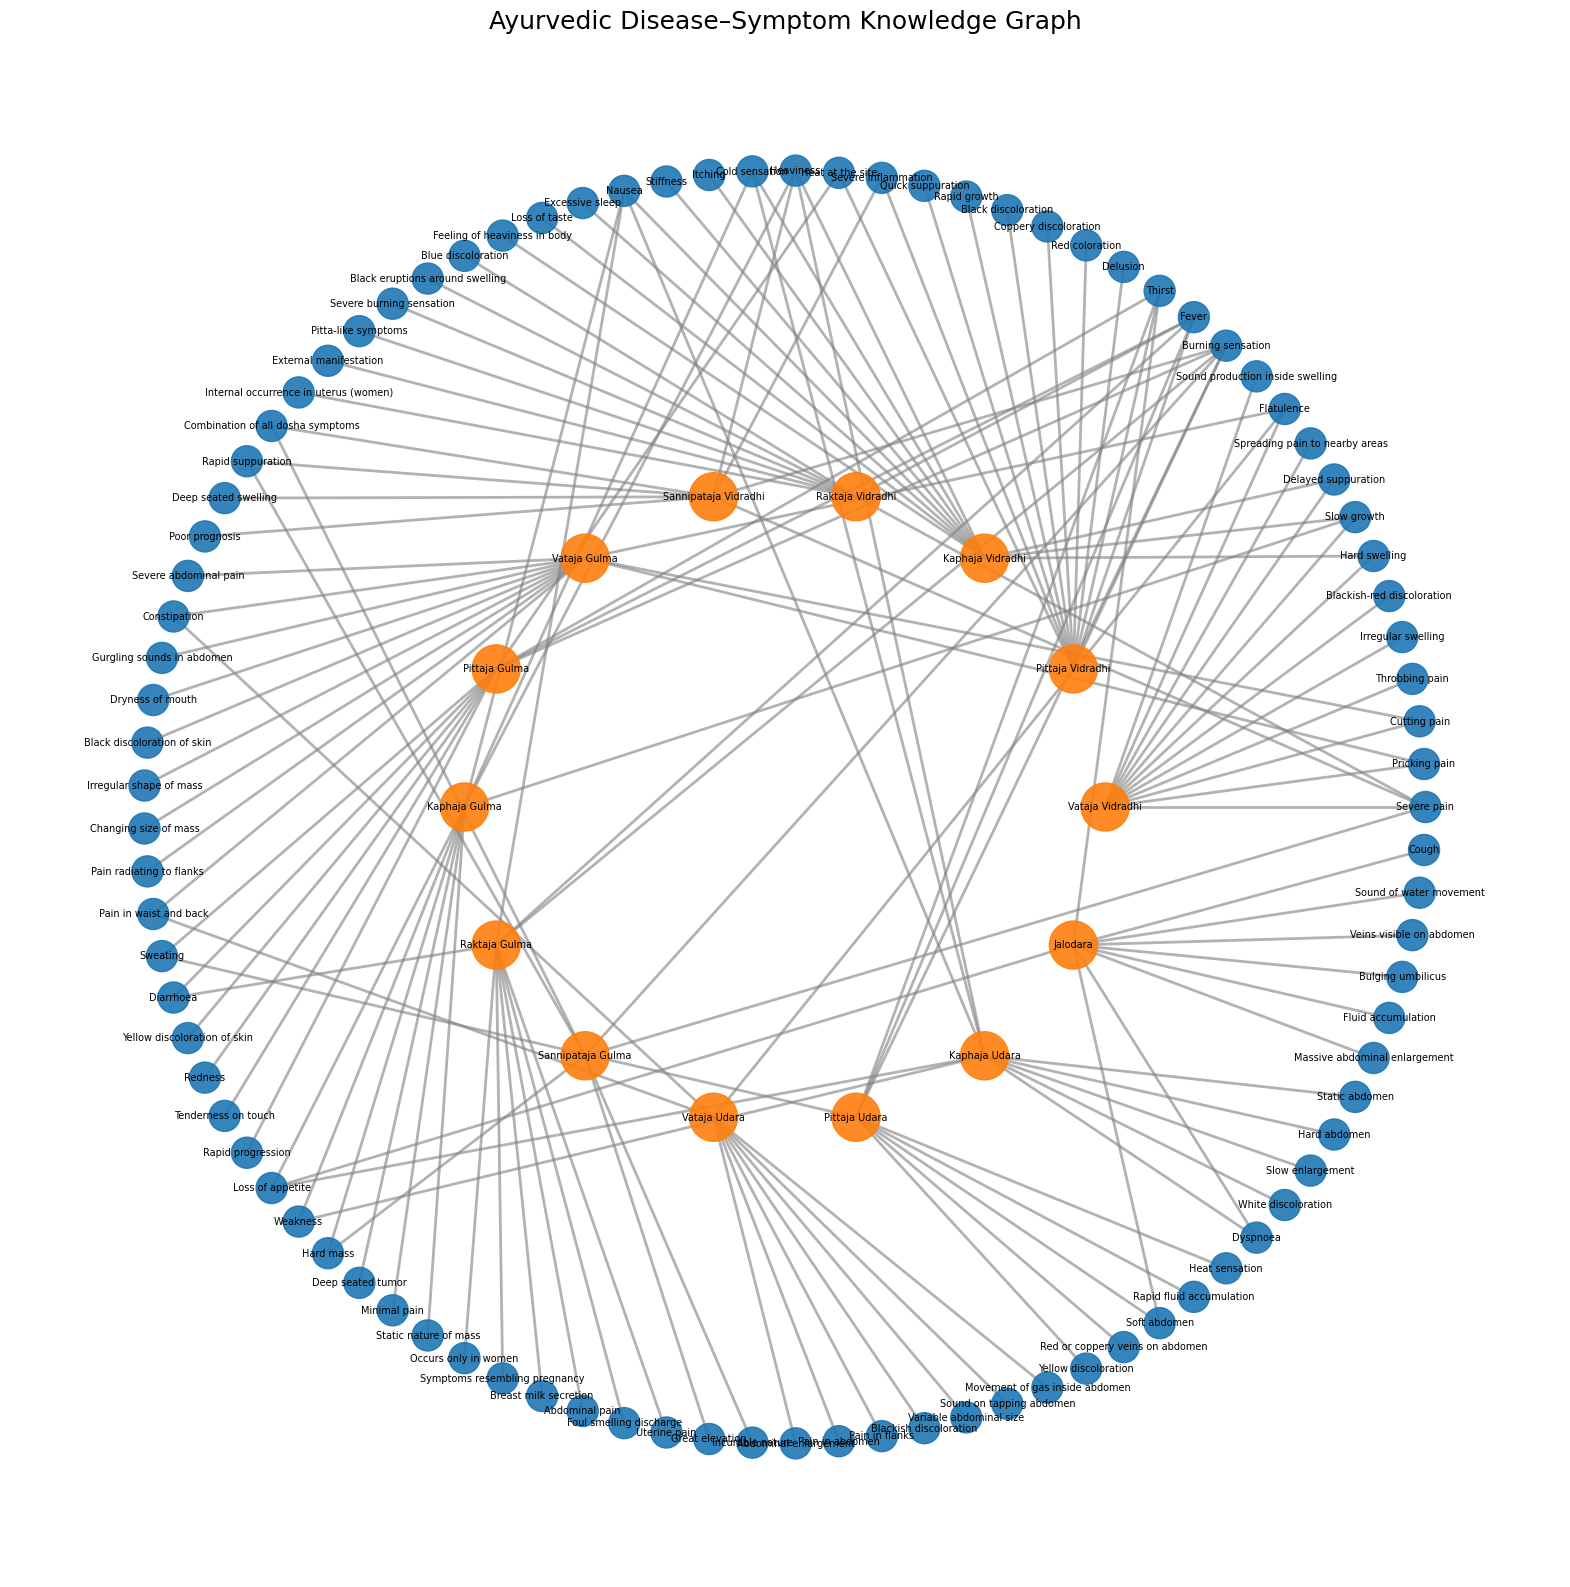

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

plt.figure(figsize=(20, 20))

pos = {}

# Radii for concentric circles
R_DISEASE = 3
R_TYPE = 6
R_SYMPTOM = 12

# Collect nodes
diseases = list(knowledge["diseases"].keys())
types = []
symptoms = []

for disease, details in knowledge["diseases"].items():
    for dtype, info in details["types"].items():
        types.append(dtype)
        for s in info["symptoms"]:
            if s not in symptoms:
                symptoms.append(s)

# ---- Disease groups (small circle at center) ----
angle_step = 2 * np.pi / len(diseases)
for i, disease in enumerate(diseases):
    angle = i * angle_step
    pos[disease] = (R_DISEASE * np.cos(angle), R_DISEASE * np.sin(angle))

# ---- Disease types (middle circle) ----
angle_step = 2 * np.pi / len(types)
for i, dtype in enumerate(types):
    angle = i * angle_step
    pos[dtype] = (R_TYPE * np.cos(angle), R_TYPE * np.sin(angle))

# ---- Symptoms (outer circle) ----
angle_step = 2 * np.pi / len(symptoms)
for i, symptom in enumerate(symptoms):
    angle = i * angle_step
    pos[symptom] = (R_SYMPTOM * np.cos(angle), R_SYMPTOM * np.sin(angle))

# Node colors & sizes
node_colors, node_sizes = [], []
for node in G.nodes():
    if node in diseases:
        node_colors.append("#d62728")  # RED → disease group
        node_sizes.append(2000)
    elif node in types:
        node_colors.append("#ff7f0e")  # ORANGE → disease type
        node_sizes.append(1200)
    else:
        node_colors.append("#1f77b4")  # BLUE → symptom
        node_sizes.append(500)

# Edge weights for visualization
weights = [G[u][v].get("weight", 1.0) for u, v in G.edges()]

# ---- DRAW GRAPH ----
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=7)
nx.draw_networkx_edges(G, pos, width=[w*2 for w in weights], edge_color="gray", alpha=0.6)

plt.title("Ayurvedic Disease–Symptom Knowledge Graph", fontsize=18)
plt.axis("off")
plt.show()


In [ ]:
def create_patient_graph(disease_type, symptom_list):

    temp_graph = nx.Graph()
    temp_graph.add_node("patient_case", node_type="patient")

    # ---- positive symptoms ----
    k = max(3, int(0.7 * len(symptom_list)))
    pos_symptoms = random.sample(symptom_list, k=k)

    for s in pos_symptoms:
        if random.random() < 0.9:
            temp_graph.add_node(s, node_type="symptom")
            temp_graph.add_edge("patient_case", s, weight=2.0)

    # ---- controlled noise (IMPORTANT CHANGE) ----
    other_symptoms = list(all_symptoms - set(symptom_list))

    noise_k = 1   # ⭐ fixed noise

    if len(other_symptoms) > 0:
        noise_samples = random.sample(
            other_symptoms,
            k=min(noise_k, len(other_symptoms))
        )

        for s in noise_samples:
            temp_graph.add_node(s, node_type="symptom")
            temp_graph.add_edge("patient_case", s, weight=0.5)

    return temp_graph

In [ ]:
symptom_to_id = {symptom: i for i, symptom in enumerate(all_symptoms)}
print("Symptom to ID mapping created.")

Symptom to ID mapping created.


In [ ]:
from torch_geometric.data import Data
import torch

def nx_to_pyg(graph, label):
    nodes = list(graph.nodes())
    idx = {node: i for i, node in enumerate(nodes)}

    # -------- edges --------
    edges = []
    edge_weights = []
    for u, v in graph.edges():
        w = graph[u][v].get("weight", 1.0)  # default weight = 1.0
        edges.append([idx[u], idx[v]])
        edge_weights.append(w)
        edges.append([idx[v], idx[u]])
        edge_weights.append(w)

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_weights, dtype=torch.float).unsqueeze(1)

    # -------- node features --------
    x = []
    for node in nodes:
        node_type = graph.nodes[node].get("node_type")

        # base type encoding
        if node_type == "disease":
            base = [1, 0, 0]
        elif node_type == "symptom":
            base = [0, 1, 0]
        else:  # patient
            base = [0, 0, 1]

        # unique hash feature
        hash_val = (hash(node) % 1000) / 1000.0
        x.append(base + [hash_val])  # now 4 features

    x = torch.tensor(x, dtype=torch.float)
    y = torch.tensor([label], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)


In [ ]:
#....... DataSet Creation..........#
dataset = []

TARGET_SAMPLES = 21000

# collect all disease types and their symptoms
types_list = []
for disease, details in knowledge["diseases"].items():
    for dtype, info in details["types"].items():
        types_list.append((dtype, info["symptoms"]))

# how many samples per type
samples_per_type = TARGET_SAMPLES // len(types_list)

# generate patient graphs and convert to PyG
for dtype, symptoms in types_list:
    for _ in range(samples_per_type):
        pg = create_patient_graph(dtype, symptoms)              # patient case graph
        pyg_graph = nx_to_pyg(pg, label_map[dtype])             # convert to PyG Data (with edge_attr)
        dataset.append(pyg_graph)

print("Total samples:", len(dataset))


Total samples: 21000


In [ ]:
print("Num classes:", len(label_map))
print("Sample graph:", dataset[0])
print("Node feature shape:", dataset[0].x.shape)

Num classes: 14
Sample graph: Data(x=[9, 4], edge_index=[2, 16], edge_attr=[16, 1], y=[1])
Node feature shape: torch.Size([9, 4])


In [ ]:
from collections import Counter

labels = [data.y.item() for data in dataset]   # get labels from dataset
counts = Counter(labels)

print("Classes with samples:", sorted(counts.keys()))
print("Expected classes:", list(range(len(label_map))))

Classes with samples: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Expected classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


In [ ]:
from collections import Counter
import torch

# device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# compute class weights
labels = [data.y.item() for data in dataset]
counts = Counter(labels)

num_classes = len(label_map)
total = len(labels)

weights = []

for i in range(num_classes):
    if i in counts:
        weights.append(total / counts[i])
    else:
        weights.append(0.0)   # safe handling if class missing

class_weights = torch.tensor(weights, dtype=torch.float).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
####......Training and testing the dataset.........####
import copy
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

# ⭐ VERY IMPORTANT — make fresh clean copy of dataset
dataset_clean = copy.deepcopy(dataset)

# split
train_data, test_data = train_test_split(
    dataset_clean,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

# loaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

Training samples: 16800
Testing samples: 4200


In [ ]:
# -------- Creating the DataLoader --------
from torch_geometric.loader import DataLoader

# ⭐ Larger batch size improves DiffPool training stability
train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True,
    drop_last=True      # ⭐ very important for dense diffpool stability
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

In [ ]:
import torch
import torch.nn.functional as F
from torch.nn import Linear

from torch_geometric.nn import GATConv, dense_diff_pool
from torch_geometric.utils import to_dense_batch, to_dense_adj

In [ ]:
# Check if edge_attr exists in your dataset
sample = dataset[0]  # take the first graph

print("Has edge_attr:", hasattr(sample, 'edge_attr'))
if hasattr(sample, 'edge_attr'):
    print("Edge attr shape:", sample.edge_attr.shape)
    print("First few edge attrs:", sample.edge_attr[:5])
else:
    print("No edge attributes found in this dataset.")


Has edge_attr: True
Edge attr shape: torch.Size([16, 1])
First few edge attrs: tensor([[2.],
        [2.],
        [2.],
        [2.],
        [2.]])


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv, dense_diff_pool, BatchNorm
from torch_geometric.utils import to_dense_batch, to_dense_adj


class GATSimple(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # -------- Message Passing --------
        self.gat1 = GATConv(4, 128, heads=4)
        self.bn1 = BatchNorm(128 * 4)

        self.gat2 = GATConv(128 * 4, 256)
        self.bn2 = BatchNorm(256)

        self.gat3 = GATConv(256, 256)
        self.bn3 = BatchNorm(256)

        # -------- DiffPool Assignment --------
        self.assign1 = torch.nn.Linear(256, 128)
        self.assign2 = torch.nn.Linear(128, 25)   # tuned cluster size

        # -------- DiffPool Embedding --------
        self.embed1 = torch.nn.Linear(256, 128)
        self.embed2 = torch.nn.Linear(128, 128)

        # -------- Classifier --------
        self.lin1 = torch.nn.Linear(128, 64)
        self.lin2 = torch.nn.Linear(64, num_classes)

        self.dropout = 0.35

    def forward(self, data):

        x, edge_index, batch = data.x, data.edge_index, data.batch
        edge_attr = data.edge_attr

        # ----- Message Passing -----
        x = self.gat1(x, edge_index, edge_attr=edge_attr)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.gat2(x, edge_index, edge_attr=edge_attr)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.gat3(x, edge_index, edge_attr=edge_attr)
        x = self.bn3(x)
        x = F.relu(x)

        # ----- Dense Conversion -----
        x_dense, mask = to_dense_batch(x, batch)
        adj = to_dense_adj(edge_index, batch)

        # ----- Assignment Matrix -----
        s = F.relu(self.assign1(x_dense))
        s = self.assign2(s)

        # ----- Node Embeddings -----
        z = F.relu(self.embed1(x_dense))
        z = self.embed2(z)

        # ----- DiffPool -----
        x_pool, adj_pool, link_loss, ent_loss = dense_diff_pool(
            z, adj, s, mask
        )

        # ----- Graph Embedding -----
        x = torch.sum(x_pool, dim=1)

        # ----- Classification -----
        x = F.relu(self.lin1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        out = self.lin2(x)

        return out, link_loss, ent_loss

In [ ]:
# Check for GPU and set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [ ]:
# Re-initializing the model and moving to device
# Re-initializing the model and moving to device

# number of classes
num_classes = len(label_map)

model = GATSimple(num_classes).to(device)

# ⭐ Optimizer (Very Stable for DiffPool)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0003,          # ⭐ reduced LR for stable clustering learning
    weight_decay=1e-4   # ⭐ L2 Regularization (correct)
)

# ⭐ Scheduler (VERY IMPORTANT for DiffPool)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=250
)

# ⭐ Class Imbalance Handling (Correct)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

print(model)

GATSimple(
  (gat1): GATConv(4, 128, heads=4)
  (bn1): BatchNorm(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gat2): GATConv(512, 256, heads=1)
  (bn2): BatchNorm(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gat3): GATConv(256, 256, heads=1)
  (bn3): BatchNorm(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (assign1): Linear(in_features=256, out_features=128, bias=True)
  (assign2): Linear(in_features=128, out_features=25, bias=True)
  (embed1): Linear(in_features=256, out_features=128, bias=True)
  (embed2): Linear(in_features=128, out_features=128, bias=True)
  (lin1): Linear(in_features=128, out_features=64, bias=True)
  (lin2): Linear(in_features=64, out_features=14, bias=True)
)


In [ ]:
def train():

    model.train()
    total_loss = 0

    for data in train_loader:

        data = data.to(device)

        optimizer.zero_grad()

        out, link_loss, ent_loss = model(data)

        ce_loss = criterion(out, data.y)

        # ⭐ Balanced DiffPool Loss (VERY IMPORTANT)
        loss = ce_loss + 0.01 * link_loss + 0.001 * ent_loss

        loss.backward()

        # ⭐ Gradient Clipping (prevents sudden accuracy drops)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [ ]:
# Test function - Modified for Bi-DiffPool + GPU

@torch.no_grad()
def test(loader):
    model.eval()
    correct = 0

    for data in loader:
        data = data.to(device)

        out, _, _ = model(data)

        pred = out.argmax(dim=1)

        correct += (pred == data.y).sum().item()

    return correct / len(loader.dataset)

In [ ]:


# -------- Train Model FINAL LOOP --------

best_test_acc = 0

train_acc_list = []
test_acc_list = []
loss_list = []

for epoch in range(1, 251):

    loss = train()     # ⭐ no need to pass epoch
    train_acc = test(train_loader)
    test_acc = test(test_loader)

    scheduler.step()   # ⭐ VERY IMPORTANT

    loss_list.append(loss)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    # ⭐ Save Best Model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "best_diffpool.pt")

    print(f"Epoch {epoch:03d} | "
          f"Loss: {loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Test Acc: {test_acc:.4f}")

# ⭐ Load Best Model After Training
model.load_state_dict(torch.load("best_diffpool.pt"))

print("⭐ BEST TEST ACCURACY:", best_test_acc)

Epoch 001 | Loss: 2.3597 | Train Acc: 0.2998 | Test Acc: 0.2967
Epoch 002 | Loss: 1.9523 | Train Acc: 0.4035 | Test Acc: 0.3907
Epoch 003 | Loss: 1.7339 | Train Acc: 0.5103 | Test Acc: 0.4976
Epoch 004 | Loss: 1.5801 | Train Acc: 0.5434 | Test Acc: 0.5371
Epoch 005 | Loss: 1.4230 | Train Acc: 0.6249 | Test Acc: 0.6193
Epoch 006 | Loss: 1.3252 | Train Acc: 0.6763 | Test Acc: 0.6738
Epoch 007 | Loss: 1.2316 | Train Acc: 0.6780 | Test Acc: 0.6667
Epoch 008 | Loss: 1.1562 | Train Acc: 0.7107 | Test Acc: 0.7083
Epoch 009 | Loss: 1.1091 | Train Acc: 0.7254 | Test Acc: 0.7148
Epoch 010 | Loss: 1.0794 | Train Acc: 0.7623 | Test Acc: 0.7524
Epoch 011 | Loss: 1.0134 | Train Acc: 0.7757 | Test Acc: 0.7717
Epoch 012 | Loss: 0.9883 | Train Acc: 0.7785 | Test Acc: 0.7779
Epoch 013 | Loss: 0.9481 | Train Acc: 0.7891 | Test Acc: 0.7881
Epoch 014 | Loss: 0.9435 | Train Acc: 0.8130 | Test Acc: 0.8062
Epoch 015 | Loss: 0.8785 | Train Acc: 0.8047 | Test Acc: 0.8112
Epoch 016 | Loss: 0.8857 | Train Acc: 0.

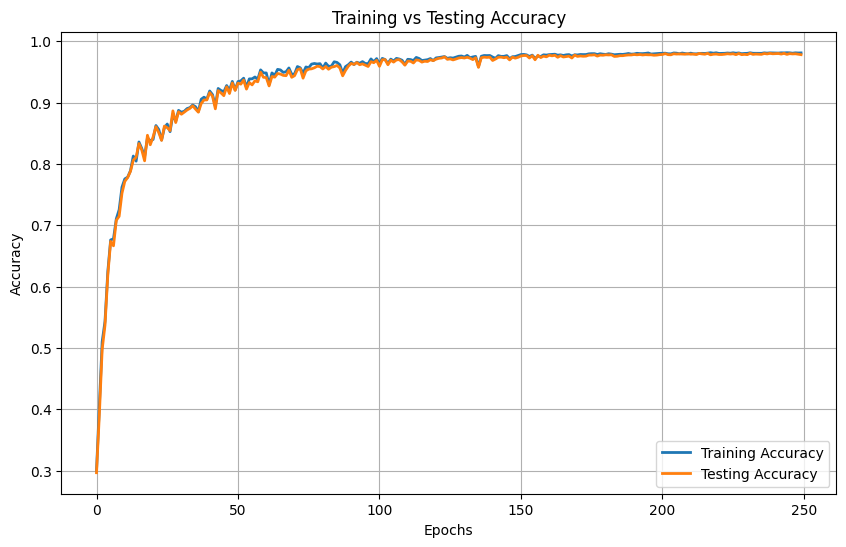

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))
plt.plot(train_acc_list, label="Training Accuracy", linewidth=2)
plt.plot(test_acc_list, label="Testing Accuracy", linewidth=2)
plt.title("Training vs Testing Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()




In [ ]:
# Final evaluation after training completes
model.eval()
test_acc = test(test_loader)
print("Final Test Accuracy:", test_acc)

Final Test Accuracy: 0.9804761904761905


In [ ]:
def predict_from_text(symptom_text):

    import torch
    import networkx as nx

    user_symptoms = [s.strip().lower() for s in symptom_text.split(",")]

    matched_symptoms = []
    for s in all_symptoms:
        if s.lower() in user_symptoms:
            matched_symptoms.append(s)

    if len(matched_symptoms) == 0:
        return "No known symptoms detected"

    temp_graph = nx.Graph()
    temp_graph.add_node("patient_case", node_type="patient")

    for s in matched_symptoms:
        temp_graph.add_node(s, node_type="symptom")
        temp_graph.add_edge("patient_case", s)

    pyg_graph = nx_to_pyg(temp_graph, 0)
    pyg_graph = pyg_graph.to(device)

    # ⭐ VERY IMPORTANT FOR DIFFPOOL
    pyg_graph.batch = torch.zeros(pyg_graph.num_nodes,
                                  dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():

        output = model(pyg_graph)

        # ⭐ handle tuple return
        if isinstance(output, tuple):
            out = output[0]
        else:
            out = output

        pred = out.argmax(dim=1).item()

    return inv_label_map[pred]

In [ ]:
#Demostrating the Predection
# -------- Demonstrating Prediction --------

import torch
import copy # Import copy module

model.eval()

# ⭐ IMPORTANT: Create a deep copy to avoid modifying the original test_data object
sample = copy.deepcopy(test_data[0]).to(device)

# ⭐ VERY IMPORTANT FOR DIFFPOOL (create batch if not present)
# The batch attribute is needed for models that expect batched input, even for a single graph.
# This modification is now on a copy, so it won't affect the DataLoader.
if not hasattr(sample, "batch") or sample.batch is None:
    sample.batch = torch.zeros(sample.num_nodes,
                               dtype=torch.long).to(device)

with torch.no_grad():

    output = model(sample)

    # ⭐ Handle both return types (tuple for DiffPool, tensor for other models)
    if isinstance(output, tuple):
        out = output[0]
    else:
        out = output

    pred = out.argmax(dim=1).item()

print("Predicted Disease:", inv_label_map[pred])
print("Actual Disease:", inv_label_map[sample.y.item()])

Predicted Disease: Pittaja Vidradhi
Actual Disease: Pittaja Vidradhi


In [ ]:
import pandas as pd
import numpy as np
import torch
import copy # Import copy module
import matplotlib.pyplot as plt
import seaborn as sns # For heatmap
from sklearn.metrics import accuracy_score, precision_recall_curve, average_precision_score, confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

# Ensure `dataset` is available from previous steps
# If `dataset` is not defined, you might need to re-run data generation cells.

# Create a fresh clean copy of dataset to prevent in-place modifications affecting subsequent runs
dataset_clean = copy.deepcopy(dataset)

# --- FIX: Explicitly clear 'batch' and 'ptr' attributes from all Data objects ---
# This prevents issues if Data objects were previously processed by a DataLoader
# and had these attributes added in-place.
for data_obj in dataset_clean:
    if hasattr(data_obj, 'batch'):
        del data_obj.batch
    if hasattr(data_obj, 'ptr'):
        del data_obj.ptr
# ----------------------------------------------------------------------------------

# Re-create train_data and test_data to ensure no in-place modifications from previous cells persist
train_data, test_data = train_test_split(
    dataset_clean,
    test_size=0.2,
    random_state=42, # Use the same random state as before
    shuffle=True
)

# Re-create test_loader with the fresh test_data
test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for data in test_loader:

        data = data.to(device)

        # Forward pass, unpack the tuple from DiffPool model
        out, _, _ = model(data)

        probs = torch.softmax(out, dim=1)

        # Get predicted labels
        pred = probs.argmax(dim=1)

        all_preds.append(pred.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

        # Flatten labels safely
        labels = data.y.view(-1).cpu().numpy()
        all_labels.append(labels)


# Convert list -> numpy arrays
all_preds = np.concatenate(all_preds, axis=0)
all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Number of classes
num_classes = all_probs.shape[1]

# Binarize labels (important for multi-class metrics like PR curve and ROC curve)
all_labels_bin = label_binarize(
    all_labels,
    classes=np.arange(num_classes)
)

print("--- Data Preparation for Metrics Complete ---")
print(f"Shape of all_preds: {all_preds.shape}")
print(f"Shape of all_probs: {all_probs.shape}")
print(f"Shape of all_labels: {all_labels.shape}")
print(f"Shape of all_labels_bin: {all_labels_bin.shape}")


--- Data Preparation for Metrics Complete ---
Shape of all_preds: (4200,)
Shape of all_probs: (4200, 14)
Shape of all_labels: (4200,)
Shape of all_labels_bin: (4200, 14)


In [ ]:
user_input = input("Enter symptoms separated by commas: ")

prediction = predict_from_text(user_input)

print("Predicted Disease:", prediction)

Enter symptoms separated by commas: pain in flanks, pain in waist and back, flatulence, constipation, variable abdominal size, pain in abdomen
Predicted Disease: Vataja Udara


### Overall Classification Metrics and Confusion Matrix

Accuracy: 0.9805

Classification Report:
                      precision    recall  f1-score   support

            Jalodara       0.99      0.99      0.99       304
       Kaphaja Gulma       0.99      0.99      0.99       279
       Kaphaja Udara       0.99      1.00      0.99       269
    Kaphaja Vidradhi       1.00      0.99      0.99       328
       Pittaja Gulma       0.97      0.98      0.98       301
       Pittaja Udara       0.95      0.95      0.95       305
    Pittaja Vidradhi       0.98      0.99      0.98       299
       Raktaja Gulma       0.97      0.96      0.97       303
    Raktaja Vidradhi       0.98      1.00      0.99       299
   Sannipataja Gulma       0.97      0.95      0.96       322
Sannipataja Vidradhi       0.95      0.96      0.95       294
        Vataja Gulma       1.00      0.99      0.99       327
        Vataja Udara       1.00      0.99      1.00       303
     Vataja Vidradhi       0.99      1.00      1.00       267

            accuracy       

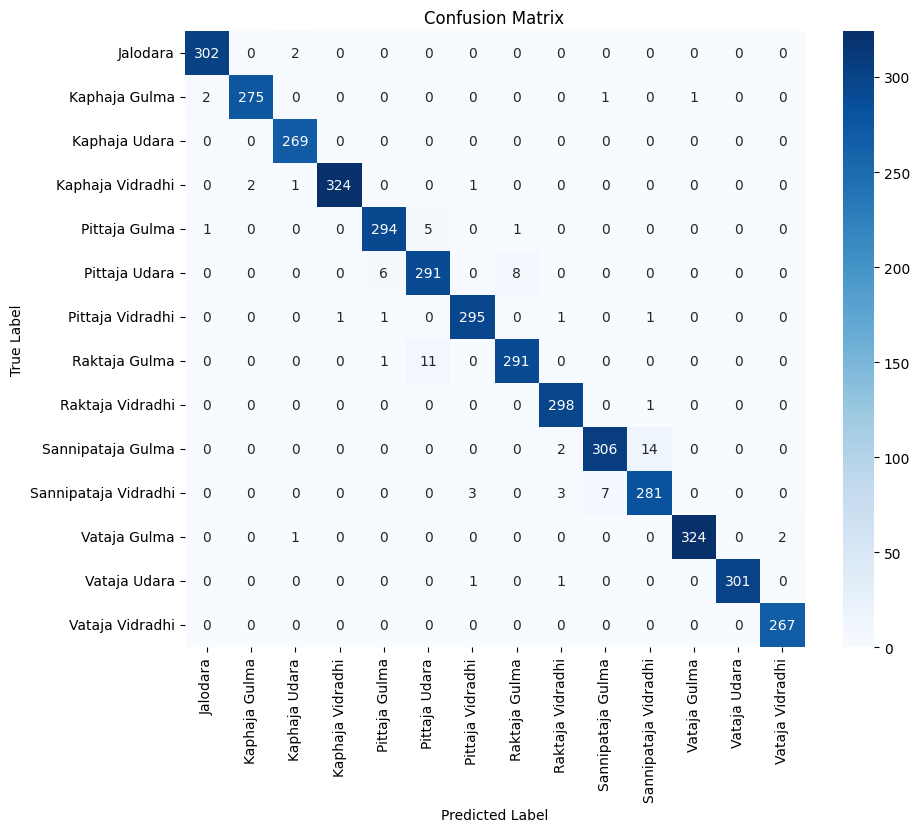

In [ ]:
# Calculate Accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report (Precision, Recall, F1-score)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=[inv_label_map[i] for i in sorted(label_map.values())]))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[inv_label_map[i] for i in sorted(label_map.values())], yticklabels=[inv_label_map[i] for i in sorted(label_map.values())])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Detailed Per-Class Metrics Table

In [ ]:
# True labels and predicted labels for per-class metrics
y_true = all_labels
y_pred = all_probs.argmax(axis=1)

# Compute metrics
precision = precision_score(y_true, y_pred, average=None)
recall = recall_score(y_true, y_pred, average=None)
f1 = f1_score(y_true, y_pred, average=None)

# Specificity from confusion matrix (reuse cm from above)
specificity = []
for i in range(num_classes):
    tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
    fp = cm[:,i].sum() - cm[i,i]
    if (tn + fp) == 0:
        specificity.append(np.nan)
    else:
        specificity.append(tn / (tn + fp))

# ROC-AUC per class
roc_auc = roc_auc_score(all_labels_bin, all_probs, average=None)

# PR-AUC (Average Precision) per class
pr_auc_scores = []
for i in range(num_classes):
    ap = average_precision_score(all_labels_bin[:, i], all_probs[:, i])
    pr_auc_scores.append(ap)

# Combine into DataFrame
metrics_df = pd.DataFrame({
    "Class Index": np.arange(num_classes),
    "Class Name": [inv_label_map[i] for i in sorted(label_map.values())],
    "Precision": precision,
    "Recall (Sensitivity)": recall,
    "Specificity": specificity,
    "F1-Score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc_scores
})

print("Detailed Classification Metrics per Class:")
display(metrics_df.round(4))

styled_df = metrics_df.style \
    .set_table_styles([{'selector': 'th',
                        'props': [('font-weight', 'bold'),
                                  ('background-color', '#f0f0f0')]}
                        ,{'selector': 'td',
                        'props': [('vertical-align', 'top')]} # Align content to top for better readability
                        ]) \
    .format("{:.3f}", subset=["Precision","Recall (Sensitivity)",
                              "Specificity","F1-Score","ROC-AUC","PR-AUC"]) \
    .set_caption("Per-Class Evaluation Metrics")

display(styled_df)

Detailed Classification Metrics per Class:


,Class Index,Class Name,Precision,Recall (Sensitivity),Specificity,F1-Score,ROC-AUC,PR-AUC
0,0,Jalodara,0.9902,0.9934,0.9992,0.9918,1.0000,0.9998
1,1,Kaphaja Gulma,0.9928,0.9857,0.9995,0.9892,1.0000,0.9997
2,2,Kaphaja Udara,0.9853,1.0000,0.9990,0.9926,1.0000,0.9999
3,3,Kaphaja Vidradhi,0.9969,0.9878,0.9997,0.9923,1.0000,0.9997
4,4,Pittaja Gulma,0.9735,0.9767,0.9979,0.9751,0.9997,0.9959
5,5,Pittaja Udara,0.9479,0.9541,0.9959,0.9510,0.9986,0.9836
6,6,Pittaja Vidradhi,0.9833,0.9866,0.9987,0.9850,0.9999,0.9986
7,7,Raktaja Gulma,0.9700,0.9604,0.9977,0.9652,0.9995,0.9938
8,8,Raktaja Vidradhi,0.9770,0.9967,0.9982,0.9868,0.9999,0.9992
9,9,Sannipataja Gulma,0.9745,0.9503,0.9979,0.9623,0.9996,0.9952


,Class Index,Class Name,Precision,Recall (Sensitivity),Specificity,F1-Score,ROC-AUC,PR-AUC
0,0,Jalodara,0.990,0.993,0.999,0.992,1.000,1.000
1,1,Kaphaja Gulma,0.993,0.986,0.999,0.989,1.000,1.000
2,2,Kaphaja Udara,0.985,1.000,0.999,0.993,1.000,1.000
3,3,Kaphaja Vidradhi,0.997,0.988,1.000,0.992,1.000,1.000
4,4,Pittaja Gulma,0.974,0.977,0.998,0.975,1.000,0.996
5,5,Pittaja Udara,0.948,0.954,0.996,0.951,0.999,0.984
6,6,Pittaja Vidradhi,0.983,0.987,0.999,0.985,1.000,0.999
7,7,Raktaja Gulma,0.970,0.960,0.998,0.965,0.999,0.994
8,8,Raktaja Vidradhi,0.977,0.997,0.998,0.987,1.000,0.999
9,9,Sannipataja Gulma,0.975,0.950,0.998,0.962,1.000,0.995


### Per-Class Metrics Comparison Bar Plot

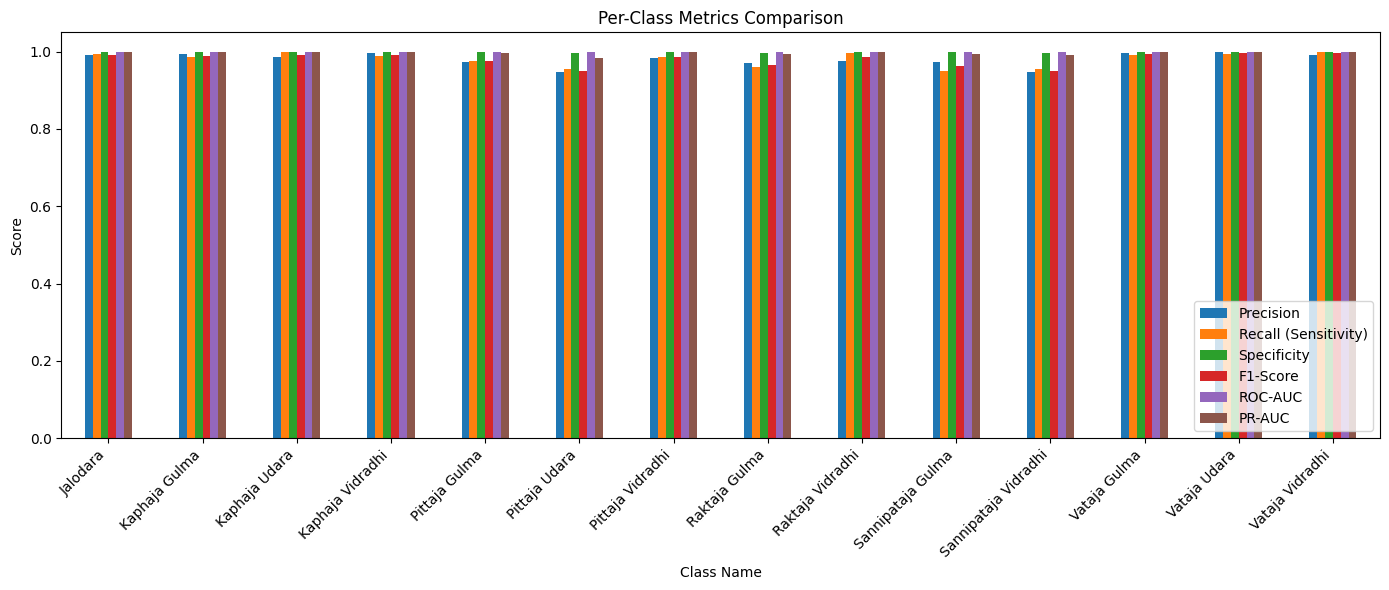

In [ ]:
metrics_to_plot = ["Precision", "Recall (Sensitivity)", "Specificity", "F1-Score", "ROC-AUC", "PR-AUC"]

# Ensure 'Class Name' is used as the index for plotting if it exists, otherwise 'Class Index'
if 'Class Name' in metrics_df.columns:
    plot_df = metrics_df.set_index("Class Name")
else:
    plot_df = metrics_df.set_index("Class Index")

plot_df[metrics_to_plot].plot(kind="bar", figsize=(14,6))
plt.title("Per-Class Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.legend(loc="lower right")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Multi-Class Precision-Recall Curve Visualization

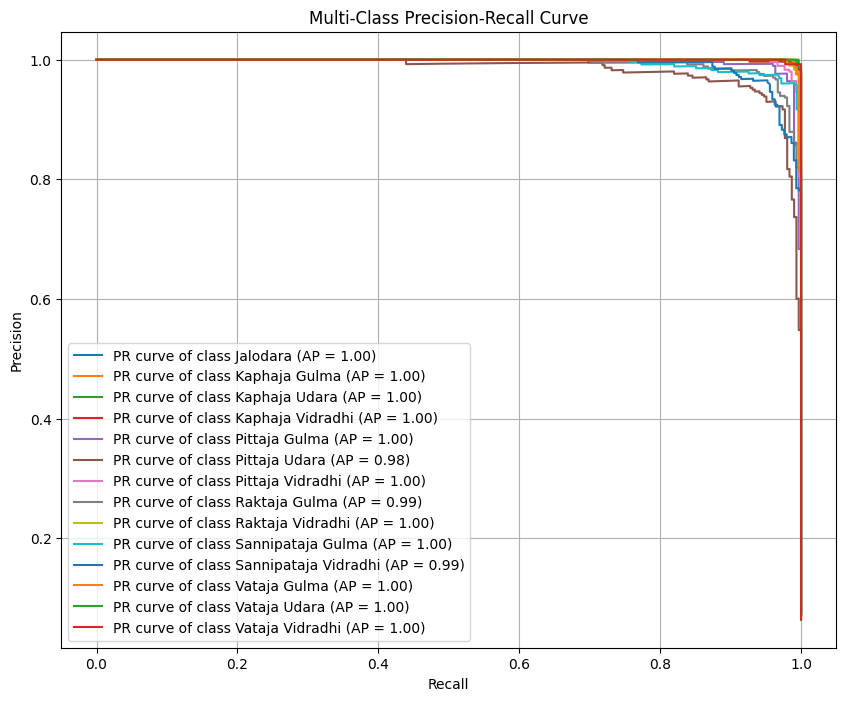

In [ ]:
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(all_labels_bin[:, i], all_probs[:, i])
    ap_score = average_precision_score(all_labels_bin[:, i], all_probs[:, i])
    plt.plot(recall, precision, label=f'PR curve of class {inv_label_map[i]} (AP = {ap_score:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Multi-Class Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

### Multi-Class ROC Curve Visualization

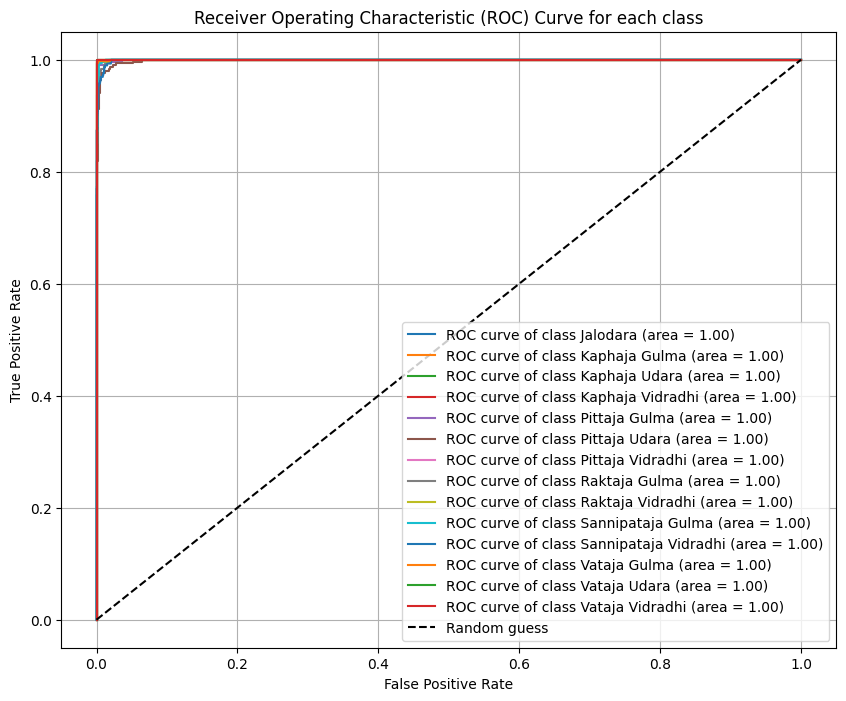

In [ ]:
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve of class {inv_label_map[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for each class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Multi-Class Precision-Recall Curve

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import numpy as np

### Classification Report and Confusion Matrix

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader
import copy # Import copy module
import torch
import numpy as np

# Create a fresh clean copy of dataset within this cell to ensure it's always defined
dataset_clean = copy.deepcopy(dataset)

# --- FIX: Explicitly clear 'batch' and 'ptr' attributes from all Data objects ---
# This prevents issues if Data objects were previously processed by a DataLoader
# and had these attributes added in-place.
for data_obj in dataset_clean:
    if hasattr(data_obj, 'batch'):
        del data_obj.batch
    if hasattr(data_obj, 'ptr'):
        del data_obj.ptr
# ----------------------------------------------------------------------------------

# Re-create train_data and test_data to ensure no in-place modifications from previous cells persist
train_data, test_data = train_test_split(
    dataset_clean,
    test_size=0.2,
    random_state=42, # Use the same random state as before
    shuffle=True
)

# Re-create test_loader with the fresh test_data
test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for data in test_loader:

        data = data.to(device)

        # Forward pass, unpack the tuple from DiffPool model
        out, _, _ = model(data)

        probs = torch.softmax(out, dim=1)

        # Get predicted labels
        pred = probs.argmax(dim=1)

        # Fix: Use append instead of extend for all_preds to store arrays
        all_preds.append(pred.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

        # Flatten labels safely
        labels = data.y.view(-1).cpu().numpy()
        all_labels.append(labels)


# Convert list \u2192 numpy
all_preds = np.concatenate(all_preds, axis=0)
all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Number of classes
num_classes = all_probs.shape[1]

# Binarize labels (important for PR curve)
all_labels_bin = label_binarize(
    all_labels,
    classes=np.arange(num_classes)
)

print("Shape preds:", all_preds.shape)
print("Shape probs:", all_probs.shape)
print("Shape labels:", all_labels.shape)
print("Shape binarized labels:", all_labels_bin.shape)

Shape preds: (4200,)
Shape probs: (4200, 14)
Shape labels: (4200,)
Shape binarized labels: (4200, 14)


### ROC Curve and AUC

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader
import copy # Import copy module
import torch
import numpy as np

# Create a fresh clean copy of dataset within this cell to ensure it's always defined
dataset_clean = copy.deepcopy(dataset)

# --- FIX: Explicitly clear 'batch' and 'ptr' attributes from all Data objects ---
# This prevents issues if Data objects were previously processed by a DataLoader
# and had these attributes added in-place.
for data_obj in dataset_clean:
    if hasattr(data_obj, 'batch'):
        del data_obj.batch
    if hasattr(data_obj, 'ptr'):
        del data_obj.ptr
# ----------------------------------------------------------------------------------

# Re-create train_data and test_data to ensure no in-place modifications from previous cells persist
train_data, test_data = train_test_split(
    dataset_clean,
    test_size=0.2,
    random_state=42, # Use the same random state as before
    shuffle=True
)

# Re-create test_loader with the fresh test_data
test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for data in test_loader:

        data = data.to(device)

        # Forward pass, unpack the tuple from DiffPool model
        out, _, _ = model(data)

        probs = torch.softmax(out, dim=1)

        # Get predicted labels
        pred = probs.argmax(dim=1)

        # Fix: Use append instead of extend for all_preds to store arrays
        all_preds.append(pred.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

        # Flatten labels safely
        labels = data.y.view(-1).cpu().numpy()
        all_labels.append(labels)


# Convert list \u2192 numpy
all_preds = np.concatenate(all_preds, axis=0)
all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Number of classes
num_classes = all_probs.shape[1]

# Binarize labels (important for PR curve)
all_labels_bin = label_binarize(
    all_labels,
    classes=np.arange(num_classes)
)

print("Shape preds:", all_preds.shape)
print("Shape probs:", all_probs.shape)
print("Shape labels:", all_labels.shape)
print("Shape binarized labels:", all_labels_bin.shape)

Shape preds: (4200,)
Shape probs: (4200, 14)
Shape labels: (4200,)
Shape binarized labels: (4200, 14)


In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize
import numpy as np # Ensure numpy is imported
from sklearn.metrics import confusion_matrix # Ensure confusion_matrix is imported

# True labels and predicted labels
y_true = all_labels

# Note: all_probs contains the probability scores, we need argmax for hard predictions
y_pred = all_probs.argmax(axis=1)

# Binarize labels for multi-class metrics where needed (e.g., ROC-AUC, PR-AUC)
num_classes = all_probs.shape[1]
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

# Compute metrics
precision = precision_score(y_true, y_pred, average=None)
recall = recall_score(y_true, y_pred, average=None)
f1 = f1_score(y_true, y_pred, average=None)

# Specificity from confusion matrix
cm = confusion_matrix(y_true, y_pred)
specificity = []
for i in range(num_classes):
    # True Negative (TN) for class i: sum of all cells not in row i and not in col i
    # False Positive (FP) for class i: sum of col i excluding cm[i,i]
    tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
    fp = cm[:,i].sum() - cm[i,i]

    if (tn + fp) == 0:
        specificity.append(np.nan) # Handle case where denominator is zero
    else:
        specificity.append(tn / (tn + fp))

# ROC-AUC per class
roc_auc = roc_auc_score(y_true_bin, all_probs, average=None)

# PR-AUC (Average Precision) per class
pr_auc = []
for i in range(num_classes):
    ap = average_precision_score(y_true_bin[:, i], all_probs[:, i])
    pr_auc.append(ap)

# Combine into DataFrame
metrics_df = pd.DataFrame({
    "Class Index": np.arange(num_classes),
    "Class Name": [inv_label_map[i] for i in sorted(label_map.values())], # Add class names for readability
    "Precision": precision,
    "Recall (Sensitivity)": recall,
    "Specificity": specificity,
    "F1-Score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
})

print("Detailed Classification Metrics per Class:")
display(metrics_df.round(4))


Detailed Classification Metrics per Class:


,Class Index,Class Name,Precision,Recall (Sensitivity),Specificity,F1-Score,ROC-AUC,PR-AUC
0,0,Jalodara,0.9902,0.9934,0.9992,0.9918,1.0000,0.9998
1,1,Kaphaja Gulma,0.9928,0.9857,0.9995,0.9892,1.0000,0.9997
2,2,Kaphaja Udara,0.9853,1.0000,0.9990,0.9926,1.0000,0.9999
3,3,Kaphaja Vidradhi,0.9969,0.9878,0.9997,0.9923,1.0000,0.9997
4,4,Pittaja Gulma,0.9735,0.9767,0.9979,0.9751,0.9997,0.9959
5,5,Pittaja Udara,0.9479,0.9541,0.9959,0.9510,0.9986,0.9836
6,6,Pittaja Vidradhi,0.9833,0.9866,0.9987,0.9850,0.9999,0.9986
7,7,Raktaja Gulma,0.9700,0.9604,0.9977,0.9652,0.9995,0.9938
8,8,Raktaja Vidradhi,0.9770,0.9967,0.9982,0.9868,0.9999,0.9992
9,9,Sannipataja Gulma,0.9745,0.9503,0.9979,0.9623,0.9996,0.9952
